In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [5]:
df = pd.read_csv("../data/loan_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [6]:
# Basic Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [7]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [8]:
# missing values
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [9]:
# duplicate values
df.duplicated().sum()

np.int64(0)

In [10]:
# traget distribution
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [11]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64

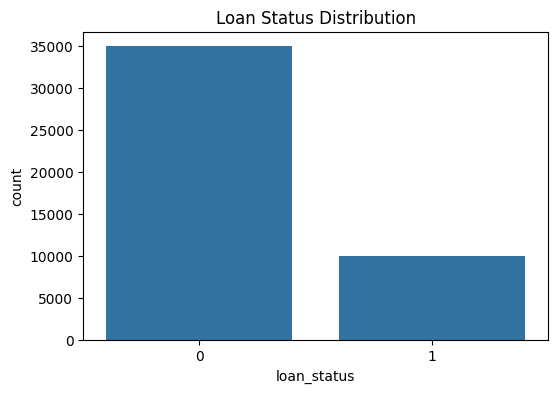

In [12]:
# data Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

In [109]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    xgb_model.feature_importances_
})

importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
12,previous_loan_defaults_on_file,0.830379
9,loan_percent_income,0.041910
5,person_home_ownership,0.033306
8,loan_int_rate,0.031140
3,person_income,0.017103
7,loan_intent,0.012977
11,credit_score,0.007569
6,loan_amnt,0.005494
0,person_age,0.004604
10,cb_person_cred_hist_length,0.003625


In [ ]:
# understanding the target

In [13]:
df.groupby('loan_status')['person_income'].mean()

loan_status
0    86157.040743
1    59886.096900
Name: person_income, dtype: float64

In [15]:
df.groupby('loan_status')['loan_percent_income'].mean()

loan_status
0    0.121783
1    0.202521
Name: loan_percent_income, dtype: float64

In [14]:
df.groupby('loan_status')['credit_score'].mean()

loan_status
0    632.814914
1    631.887200
Name: credit_score, dtype: float64

In [17]:
# Feature engineering
df['experience_ratio'] = (df['person_emp_exp'] /df['person_age'])
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,experience_ratio
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,0.000000
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,0.000000
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,0.120000
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,0.000000
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,0.041667


In [18]:
X = df.drop('loan_status',axis=1)
y = df['loan_status']

In [19]:
X.dtypes

person_age                        float64
person_gender                         str
person_education                      str
person_income                     float64
person_emp_exp                      int64
person_home_ownership                 str
loan_amnt                         float64
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file        str
experience_ratio                  float64
dtype: object

In [20]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

C:\Users\Soumyadip Das\AppData\Local\Temp\ipykernel_15404\4234782203.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


In [21]:
X.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,experience_ratio
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,0.000000
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0.000000
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,0.120000
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,0.000000
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,0.041667


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

#### Logistic Regression

In [24]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression Evaluation: \n")
print("Classification Report: \n",classification_report(y_test,lr_pred))
print("Accuracy Score: ",accuracy_score(y_test,lr_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test, lr_pred))

Logistic Regression Evaluation: 

Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Accuracy Score:  0.8974444444444445
Confusion Matrix: 
 [[6573  427]
 [ 496 1504]]


#### Decion Tree

In [37]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=6,min_samples_split=20,min_samples_leaf=10,random_state=42)
dt_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [38]:
dt_pred = dt_model.predict(X_test)

In [39]:
print("Decision Tree Evaluation: \n")
print("Classification Report: \n",classification_report(y_test,dt_pred))
print("Accuracy Score: ",accuracy_score(y_test,dt_pred))

Decision Tree Evaluation: 

Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7000
           1       0.88      0.70      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.90      0.84      0.86      9000
weighted avg       0.91      0.91      0.91      9000

Accuracy Score:  0.913


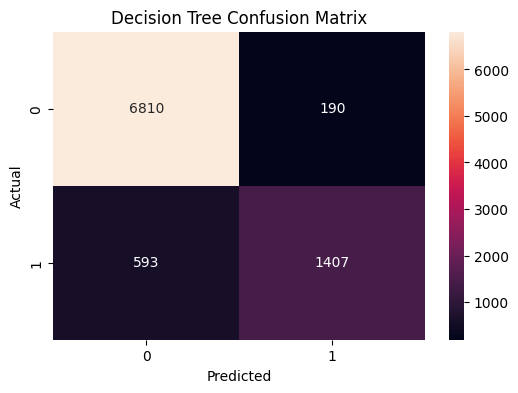

In [40]:
cm = confusion_matrix(y_test,dt_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
# Feature Importance
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    dt_model.feature_importances_
})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

importance_df.head(10)

,Feature,Importance
12,previous_loan_defaults_on_file,0.456916
9,loan_percent_income,0.197409
8,loan_int_rate,0.190360
3,person_income,0.087222
5,person_home_ownership,0.058934
7,loan_intent,0.007221
11,credit_score,0.001456
0,person_age,0.000482
1,person_gender,0.000000
2,person_education,0.000000


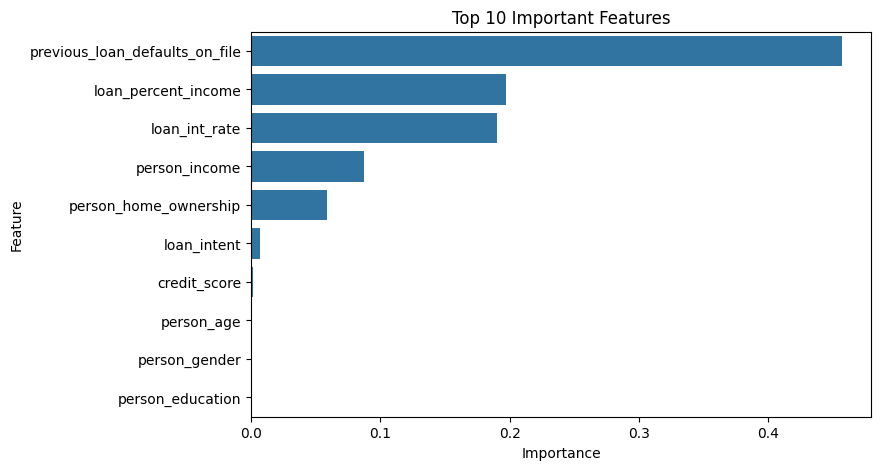

In [47]:
plt.figure(
    figsize=(8,5)
)

sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [41]:
train_score = dt_model.score(
    
    X_train,
    
    y_train
)

test_score = dt_model.score(
    
    X_test,
    
    y_test
)

print(
    "Train Accuracy:",
    train_score
)

print(
    "Test Accuracy:",
    test_score
)

Train Accuracy: 0.9169444444444445
Test Accuracy: 0.913


#### Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200,max_depth=10, min_samples_split=10,min_samples_leaf=5,random_state=42,n_jobs=-1)

rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [43]:
rf_pred = rf_model.predict(X_test)

In [44]:
print("Random Forest Evaluation: \n")
print("Classification Report: \n",classification_report(y_test,rf_pred))
print("Accuracy Score: ",accuracy_score(y_test,rf_pred))

Random Forest Evaluation: 

Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7000
           1       0.90      0.72      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.91      0.85      0.88      9000
weighted avg       0.92      0.92      0.92      9000

Accuracy Score:  0.92


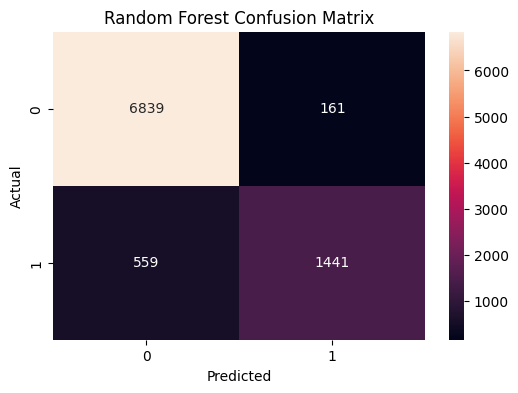

In [45]:
cm = confusion_matrix(
    
    y_test,
    
    rf_pred
)

plt.figure(
    figsize=(6,4)
)

sns.heatmap(
    
    cm,
    
    annot=True,
    
    fmt='d'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [48]:
#feature Importance
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf_model.feature_importances_
})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

importance_df.head(15)

,Feature,Importance
12,previous_loan_defaults_on_file,0.337756
9,loan_percent_income,0.203903
8,loan_int_rate,0.163150
3,person_income,0.111247
5,person_home_ownership,0.090268
6,loan_amnt,0.033750
7,loan_intent,0.021242
11,credit_score,0.018834
13,experience_ratio,0.004984
0,person_age,0.004751


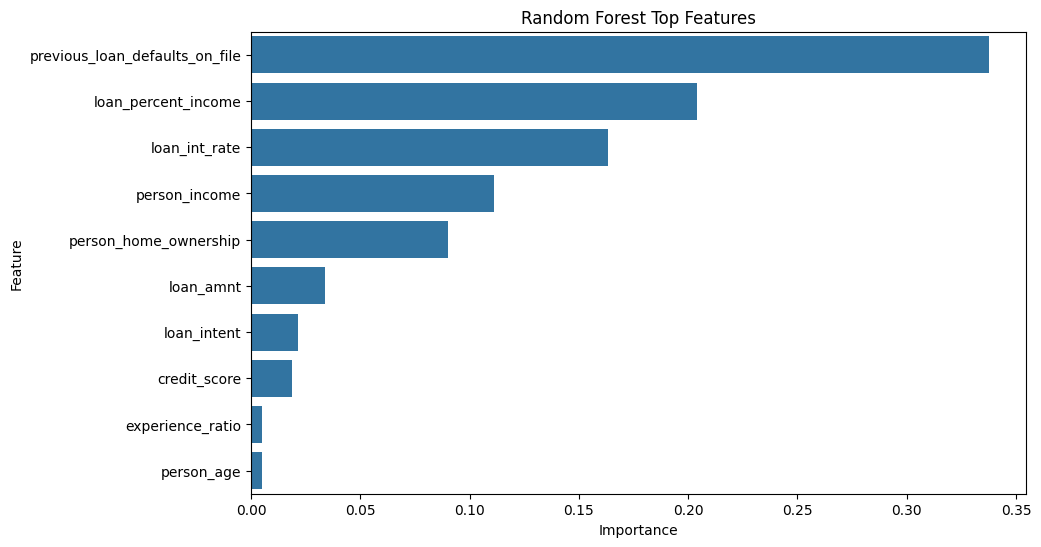

In [49]:
plt.figure(
    figsize=(10,6)
)

sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature"
)

plt.title(
    "Random Forest Top Features"
)

plt.show()

In [50]:
train_score = rf_model.score(
    
    X_train,
    
    y_train
)

test_score = rf_model.score(
    
    X_test,
    
    y_test
)

print(
    "Train Accuracy:",
    train_score
)

print(
    "Test Accuracy:",
    test_score
)

Train Accuracy: 0.9286944444444445
Test Accuracy: 0.92


In [51]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(
    
    X_test
)

rf_auc = roc_auc_score(
    
    y_test,
    
    rf_prob[:,1]
)

print(
    "ROC-AUC:",
    rf_auc
)

ROC-AUC: 0.9695133571428571


#### XGBoost

In [53]:
from xgboost import XGBClassifier

In [54]:
negative_class = (y_train == 0).sum()

positive_class = (y_train == 1).sum()

scale_weight = (negative_class / positive_class)

print(scale_weight)

3.5


In [55]:
xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=3,

    subsample=0.8,

    colsample_bytree=0.8,

    gamma=0.2,

    reg_alpha=1,

    reg_lambda=2,

    scale_pos_weight=scale_weight,

    random_state=42
)

xgb_model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [56]:
xgb_pred = xgb_model.predict(X_test)

In [58]:
print("XGBoost Evaluation: \n")
print("Classification Report: \n",classification_report(y_test,xgb_pred))
print("Accuracy Score: ",accuracy_score(y_test,xgb_pred))

XGBoost Evaluation: 

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.90      0.94      7000
           1       0.73      0.92      0.81      2000

    accuracy                           0.91      9000
   macro avg       0.85      0.91      0.88      9000
weighted avg       0.92      0.91      0.91      9000

Accuracy Score:  0.9065555555555556


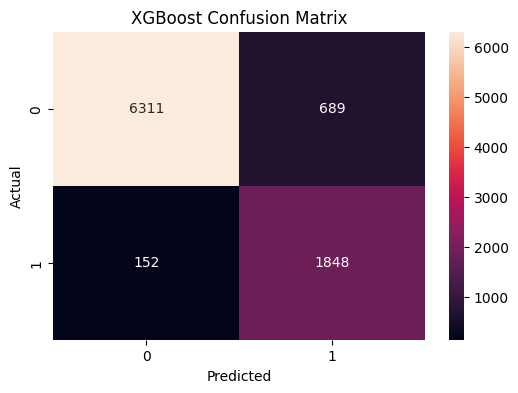

In [59]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [61]:
# probablity prediction
xgb_prob = xgb_model.predict_proba(X_test)

approval_probability = (xgb_prob[:,1])
print(approval_probability)

[0.0130544  0.00014565 0.00010511 ... 0.00075436 0.00047531 0.00036948]


In [62]:
xgb_auc = roc_auc_score(y_test,approval_probability)

print("ROC-AUC:",xgb_auc)

ROC-AUC: 0.9775851428571429


In [63]:
importance_df = pd.DataFrame({"Feature": X.columns, "Importance": xgb_model.feature_importances_})

importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df.head(15)

,Feature,Importance
12,previous_loan_defaults_on_file,0.830379
9,loan_percent_income,0.041910
5,person_home_ownership,0.033306
8,loan_int_rate,0.031140
3,person_income,0.017103
7,loan_intent,0.012977
11,credit_score,0.007569
6,loan_amnt,0.005494
0,person_age,0.004604
10,cb_person_cred_hist_length,0.003625


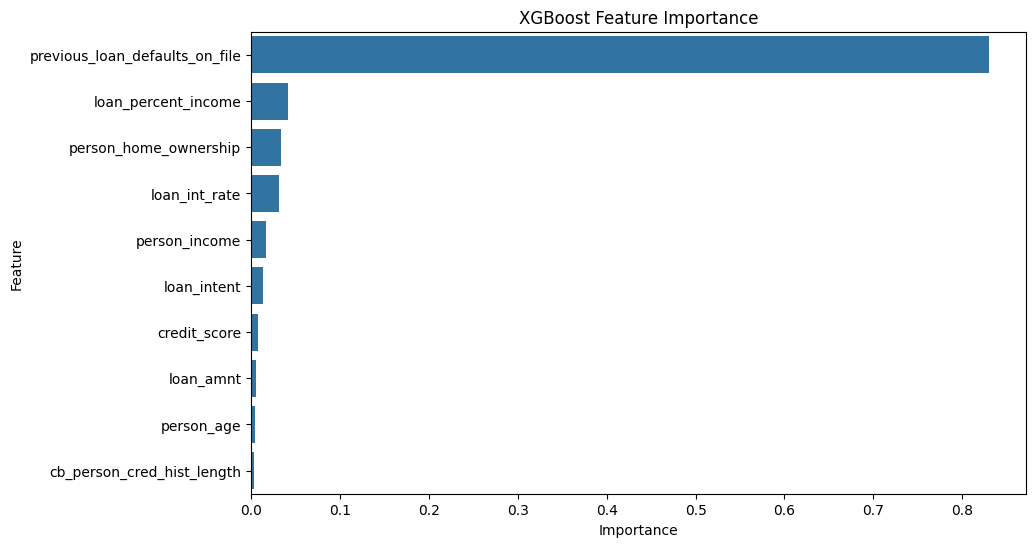

In [64]:
plt.figure(
    figsize=(10,6)
)

sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

In [65]:
train_score = xgb_model.score(
    X_train,
    y_train
)

test_score = xgb_model.score(
    X_test,
    y_test
)

print(
    "Train Accuracy:",
    train_score
)

print(
    "Test Accuracy:",
    test_score
)

Train Accuracy: 0.9161666666666667
Test Accuracy: 0.9065555555555556


#### Comparison Table

In [66]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "XGBoost"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            dt_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        ),

        accuracy_score(
            y_test,
            xgb_pred
        )
    ]
})

results.sort_values(

    by="Accuracy",

    ascending=False
)

,Model,Accuracy
2,Random Forest,0.920000
1,Decision Tree,0.913000
3,XGBoost,0.906556
0,Logistic Regression,0.897444


In [67]:
best_model = xgb_model

print("Best Model Selected: XGBoost")

Best Model Selected: XGBoost


### Production Pipeline

In [68]:
pipeline_df = df.copy()

pipeline_df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,experience_ratio
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,0.000000
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,0.000000
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,0.120000
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,0.000000
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,0.041667


In [69]:
pipeline_df["experience_ratio"] = (

    pipeline_df["person_emp_exp"] /

    pipeline_df["person_age"].replace(0,1)
)

In [70]:
# features and target 
X_pipeline = pipeline_df.drop(
    "loan_status",
    axis=1
)

y_pipeline = pipeline_df[
    "loan_status"
]

In [71]:
# Numerical Features
numerical_features = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score",
    "experience_ratio"
]

# Categorical Features
categorical_features = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

In [72]:
X_train_pipeline, X_test_pipeline, y_train_pipeline, y_test_pipeline = train_test_split(

    X_pipeline,

    y_pipeline,

    test_size=0.20,

    random_state=42,

    stratify=y_pipeline
)

In [73]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (

    OneHotEncoder,

    StandardScaler
)

In [74]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            numerical_features
        ),

        (

            "cat",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_features
        )
    ]
)

In [75]:
# pipeline import
from sklearn.pipeline import Pipeline

In [76]:
negative_class = (
    y_train_pipeline == 0
).sum()

positive_class = (
    y_train_pipeline == 1
).sum()

scale_weight = (

    negative_class /

    positive_class
)

print(scale_weight)

3.5


In [77]:
xgb_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor
        ),

        (

            "model",

            XGBClassifier(

                n_estimators=400,

                learning_rate=0.02,

                max_depth=4,

                min_child_weight=5,

                subsample=0.8,

                colsample_bytree=0.8,

                gamma=0.3,

                reg_alpha=1,

                reg_lambda=2,

                scale_pos_weight=scale_weight,

                random_state=42
            )
        )
    ]
)

In [78]:
xgb_pipeline.fit(X_train_pipeline, y_train_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [79]:
pipeline_pred = xgb_pipeline.predict(

    X_test_pipeline
)

print(

    classification_report(

        y_test_pipeline,

        pipeline_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.88      0.93      7000
           1       0.69      0.92      0.79      2000

    accuracy                           0.89      9000
   macro avg       0.83      0.90      0.86      9000
weighted avg       0.91      0.89      0.89      9000



In [80]:
print(

    accuracy_score(

        y_test_pipeline,

        pipeline_pred
    )
)

0.8894444444444445


In [81]:
probabilities = xgb_pipeline.predict_proba(

    X_test_pipeline
)

approval_probs = probabilities[:,1]

approval_probs[:10]

array([5.1461242e-02, 5.8087986e-04, 4.9923896e-04, 1.2276267e-03,
       9.4401026e-01, 7.6597428e-01, 2.2382057e-01, 9.0220501e-04,
       4.6881741e-01, 5.5401057e-01], dtype=float32)

In [82]:
# Calibration
from sklearn.calibration import CalibratedClassifierCV

In [83]:
calibrated_model = CalibratedClassifierCV(

    xgb_pipeline,

    method="sigmoid",

    cv=3
)


In [84]:
calibrated_model.fit(X_train_pipeline,y_train_pipeline)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the col

In [85]:
calibrated_pred = calibrated_model.predict(

    X_test_pipeline
)

In [86]:
print(

    classification_report(

        y_test_pipeline,

        calibrated_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7000
           1       0.82      0.83      0.83      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.89      0.89      9000
weighted avg       0.92      0.92      0.92      9000



In [87]:
probabilities = calibrated_model.predict_proba(

    X_test_pipeline
)

approval_probs = probabilities[:,1]

approval_probs[:20]

array([0.00588684, 0.00393822, 0.00393524, 0.00396005, 0.88892542,
       0.68578329, 0.02338469, 0.00394883, 0.15839901, 0.26837365,
       0.00397081, 0.00395774, 0.00945119, 0.56346241, 0.34650199,
       0.23176953, 0.00396413, 0.00396772, 0.31652922, 0.00396701])

In [90]:
# save the pipeline
import joblib
joblib.dump(

    calibrated_model,

    "../models/loan_pipeline.pkl"
)

['../models/loan_pipeline.pkl']

In [91]:
loaded_pipeline = joblib.load(

    "../models/loan_pipeline.pkl"
)

print(loaded_pipeline)

CalibratedClassifierCV(cv=3,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   StandardScaler(),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_exp',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_len

#### User Input Function

In [92]:
def prepare_user_input(

    age,
    gender,
    education,
    income,
    experience,
    home_ownership,
    loan_amount,
    loan_intent,
    interest_rate,
    credit_score,
    previous_defaults
):

    experience_ratio = (
        experience /
        max(age,1)
    )

    loan_percent_income = (
        loan_amount /
        max(income,1)
    )

    cred_hist_length = min(
        max(experience+3,2),
        25
    )

    return pd.DataFrame([{

        "person_age": age,

        "person_gender": gender,

        "person_education": education,

        "person_income": income,

        "person_emp_exp": experience,

        "person_home_ownership": home_ownership,

        "loan_amnt": loan_amount,

        "loan_intent": loan_intent,

        "loan_int_rate": interest_rate,

        "loan_percent_income": loan_percent_income,

        "cb_person_cred_hist_length": cred_hist_length,

        "credit_score": credit_score,

        "previous_loan_defaults_on_file":
        previous_defaults,

        "experience_ratio":
        experience_ratio
    }])

In [93]:
# Test data

test_user = prepare_user_input(

    age=30,

    gender="male",

    education="Bachelor",

    income=50000,

    experience=5,

    home_ownership="RENT",

    loan_amount=10000,

    loan_intent="PERSONAL",

    interest_rate=10,

    credit_score=650,

    previous_defaults="No"
)

In [94]:
prob = loaded_pipeline.predict_proba(test_user)
prediction = loaded_pipeline.predict(test_user)
print(prob)
print(prediction)

[[0.83536797 0.16463203]]
[0]


#### Testing

In [95]:
print(loaded_pipeline.classes_)

[0 1]


In [96]:
pipeline_df.groupby("loan_status")["person_income"].mean()

loan_status
0    86157.040743
1    59886.096900
Name: person_income, dtype: float64

In [97]:
pipeline_df.groupby("loan_status")["loan_percent_income"].mean()

loan_status
0    0.121783
1    0.202521
Name: loan_percent_income, dtype: float64

In [98]:
pipeline_df.groupby("loan_status")["loan_int_rate"].mean()

loan_status
0    10.477981
1    12.856794
Name: loan_int_rate, dtype: float64

In [99]:
pipeline_df.groupby("loan_status")["credit_score"].mean()

loan_status
0    632.814914
1    631.887200
Name: credit_score, dtype: float64

In [104]:
# strong applicant
strong_user = prepare_user_input(

    age=35,

    gender="male",

    education="Master",

    income=300000,

    experience=12,

    home_ownership="OWN",

    loan_amount=10000,

    loan_intent="PERSONAL",

    interest_rate=7,

    credit_score=820,

    previous_defaults="No"
)

prob = loaded_pipeline.predict_proba(
    strong_user
)

prediction = loaded_pipeline.predict(
    strong_user
)

print("Probabilities:")
print(prob)

print("\nPrediction for strong applicant:")
print(prediction)

Probabilities:
[[0.99543428 0.00456572]]

Prediction for strong applicant:
[0]


In [105]:
# Medium-risk applicant
medium_user = prepare_user_input(

    age=30,

    gender="male",

    education="Bachelor",

    income=50000,

    experience=5,

    home_ownership="RENT",

    loan_amount=10000,

    loan_intent="PERSONAL",

    interest_rate=10,

    credit_score=650,

    previous_defaults="No"
)

prob = loaded_pipeline.predict_proba(
    medium_user
)

prediction = loaded_pipeline.predict(
    medium_user
)

print(prob)
print("Prediction for Medium applicant:",prediction)

[[0.83536797 0.16463203]]
Prediction for Medium applicant: [0]


In [106]:
# High-risk applicant
high_risk_user = prepare_user_input(

    age=22,

    gender="male",

    education="High School",

    income=25000,

    experience=1,

    home_ownership="RENT",

    loan_amount=50000,

    loan_intent="VENTURE",

    interest_rate=24,

    credit_score=520,

    previous_defaults="Yes"
)

prob = loaded_pipeline.predict_proba(
    high_risk_user
)

prediction = loaded_pipeline.predict(
    high_risk_user
)

print(prob)
print("Prediction for high risk applicant: ",prediction)

[[0.99584614 0.00415386]]
Prediction for high risk applicant:  [0]


In [107]:
pipeline_df.groupby(
    'previous_loan_defaults_on_file'
)['loan_status'].value_counts()

previous_loan_defaults_on_file  loan_status
No                              0              12142
                                1              10000
Yes                             0              22858
Name: count, dtype: int64

In [108]:
pd.crosstab(
    pipeline_df['previous_loan_defaults_on_file'],
    pipeline_df['loan_status'],
    normalize='index'
)

loan_status,0,1
previous_loan_defaults_on_file,,
No,0.54837,0.45163
Yes,1.00000,0.00000


In [110]:
pipeline_df['previous_loan_defaults_on_file'].value_counts()

previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64

In [111]:
high_risk_user = prepare_user_input(

    age=22,
    gender="male",
    education="High School",
    income=25000,
    experience=1,
    home_ownership="RENT",
    loan_amount=50000,
    loan_intent="VENTURE",
    interest_rate=24,
    credit_score=520,
    previous_defaults="No"   # changed
)

prob = loaded_pipeline.predict_proba(high_risk_user)
pred = loaded_pipeline.predict(high_risk_user)

print(prob)
print(pred)

[[0.07654878 0.92345122]]
[1]


### Model version 2 without previous loan default features

In [112]:
pipeline_df_v2 = pipeline_df.copy()

In [113]:
pipeline_df_v2 = pipeline_df_v2.drop(
    "previous_loan_defaults_on_file",
    axis=1
)

In [114]:
pipeline_df_v2.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status', 'experience_ratio'],
      dtype='str')

In [115]:
# features and target
X_v2 = pipeline_df_v2.drop(
    "loan_status",
    axis=1
)

y_v2 = pipeline_df_v2[
    "loan_status"
]

In [116]:
# NUmerical Features
numerical_features_v2 = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score",
    "experience_ratio"
]

# Categorical Features
categorical_features_v2 = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent"
]

In [117]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(

    X_v2,

    y_v2,

    test_size=0.20,

    random_state=42,

    stratify=y_v2
)

In [118]:
preprocessor_v2 = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            numerical_features_v2
        ),

        (

            "cat",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_features_v2
        )
    ]
)

In [119]:
negative_class = (
    y_train_v2 == 0
).sum()

positive_class = (
    y_train_v2 == 1
).sum()

scale_weight_v2 = (

    negative_class /

    positive_class
)

print(scale_weight_v2)

3.5


In [120]:
# New pipeline
xgb_pipeline_v2 = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor_v2
        ),

        (

            "model",

            XGBClassifier(

                n_estimators=400,

                learning_rate=0.02,

                max_depth=4,

                min_child_weight=5,

                subsample=0.8,

                colsample_bytree=0.8,

                gamma=0.3,

                reg_alpha=1,

                reg_lambda=2,

                scale_pos_weight=scale_weight_v2,

                random_state=42
            )
        )
    ]
)

In [121]:
xgb_pipeline_v2.fit(X_train_v2,y_train_v2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [122]:
pred_v2 = xgb_pipeline_v2.predict(X_test_v2)

In [123]:
acc_v2 = accuracy_score(y_test_v2,pred_v2)
print(acc_v2)

0.8772222222222222


In [124]:
prob_v2 = xgb_pipeline_v2.predict_proba(

    X_test_v2
)

auc_v2 = roc_auc_score(

    y_test_v2,

    prob_v2[:,1]
)

print(auc_v2)

0.9217271785714287


In [125]:
print(

    classification_report(

        y_test_v2,

        pred_v2
    )
)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      7000
           1       0.70      0.78      0.74      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.84      0.83      9000
weighted avg       0.88      0.88      0.88      9000



In [130]:
feature_names = xgb_pipeline_v2.named_steps[
    "preprocessor"
].get_feature_names_out()

model_v2 = xgb_pipeline_v2.named_steps[
    "model"
]

importance_v2 = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
    model_v2.feature_importances_
})

importance_v2 = importance_v2.sort_values(
    by="Importance",
    ascending=False
)

display(
    importance_v2.head(20)
)

,Feature,Importance
5,num__loan_percent_income,0.177340
19,cat__person_home_ownership_RENT,0.163754
4,num__loan_int_rate,0.138394
16,cat__person_home_ownership_MORTGAGE,0.066373
1,num__person_income,0.065790
25,cat__loan_intent_VENTURE,0.056802
18,cat__person_home_ownership_OWN,0.052002
22,cat__loan_intent_HOMEIMPROVEMENT,0.048264
20,cat__loan_intent_DEBTCONSOLIDATION,0.040445
21,cat__loan_intent_EDUCATION,0.037280


In [131]:
print(acc_v2)

print(auc_v2)

0.8772222222222222
0.9217271785714287


In [132]:
# calibration for strong model 
from sklearn.calibration import CalibratedClassifierCV

In [133]:
calibrated_model_v2 = CalibratedClassifierCV(

    xgb_pipeline_v2,

    method="sigmoid",

    cv=3
)
calibrated_model_v2.fit(

    X_train_v2,

    y_train_v2
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the col

In [134]:
pred_cal_v2 = calibrated_model_v2.predict(
    X_test_v2
)

prob_cal_v2 = calibrated_model_v2.predict_proba(
    X_test_v2
)

In [135]:
print(
    accuracy_score(
        y_test_v2,
        pred_cal_v2
    )
)

print(
    roc_auc_score(
        y_test_v2,
        prob_cal_v2[:,1]
    )
)

0.9012222222222223
0.9211702857142857


In [136]:
joblib.dump(

    calibrated_model_v2,

    "../models/loan_pipeline_v2.pkl"
)

['../models/loan_pipeline_v2.pkl']

#### New test function for v2

In [137]:
def prepare_user_input_v2(

    age,
    gender,
    education,
    income,
    experience,
    home_ownership,
    loan_amount,
    loan_intent,
    interest_rate,
    credit_score
):

    experience_ratio = (
        experience /
        max(age, 1)
    )

    loan_percent_income = (
        loan_amount /
        max(income, 1)
    )

    cred_hist_length = min(
        max(experience + 3, 2),
        25
    )

    return pd.DataFrame([{

        "person_age": age,

        "person_gender": gender,

        "person_education": education,

        "person_income": income,

        "person_emp_exp": experience,

        "person_home_ownership": home_ownership,

        "loan_amnt": loan_amount,

        "loan_intent": loan_intent,

        "loan_int_rate": interest_rate,

        "loan_percent_income": loan_percent_income,

        "cb_person_cred_hist_length": cred_hist_length,

        "credit_score": credit_score,

        "experience_ratio": experience_ratio
    }])

In [138]:
strong_user = prepare_user_input_v2(

    age=35,

    gender="male",

    education="Master",

    income=300000,

    experience=12,

    home_ownership="OWN",

    loan_amount=10000,

    loan_intent="PERSONAL",

    interest_rate=7,

    credit_score=820
)

prob = calibrated_model_v2.predict_proba(
    strong_user
)

pred = calibrated_model_v2.predict(
    strong_user
)

print("Strong Applicant")
print(prob)
print(pred)

Strong Applicant
[[0.98850639 0.01149361]]
[0]


In [139]:
medium_user = prepare_user_input_v2(

    age=30,

    gender="male",

    education="Bachelor",

    income=50000,

    experience=5,

    home_ownership="RENT",

    loan_amount=10000,

    loan_intent="PERSONAL",

    interest_rate=10,

    credit_score=650
)

prob = calibrated_model_v2.predict_proba(
    medium_user
)

pred = calibrated_model_v2.predict(
    medium_user
)

print("Medium Applicant")
print(prob)
print(pred)

Medium Applicant
[[0.94465037 0.05534963]]
[0]


In [ ]:
high_risk_user = prepare_user_input_v2(
    age=22,
    gender="male",
    education="High School",
    income=25000,
    experience=1,
    home_ownership="RENT",
    loan_amount=50000,
    loan_intent="VENTURE",
    interest_rate=24,
    credit_score=520
)

prob = calibrated_model_v2.predict_proba(
    high_risk_user
)
pred = calibrated_model_v2.predict(
    high_risk_user
)

print("High Risk Applicant")
print(prob)
print(pred)

High Risk Applicant
[[0.08254233 0.91745767]]
[1]


In [ ]:
borderline_user = prepare_user_input_v2(
    age=25,
    gender="female",
    education="Bachelor",
    income=40000,
    experience=2,
    home_ownership="RENT",
    loan_amount=18000,
    loan_intent="EDUCATION",
    interest_rate=14,
    credit_score=620
)

prob = calibrated_model_v2.predict_proba(
    borderline_user
)
pred = calibrated_model_v2.predict(
    borderline_user
)
print("Borderline Applicant")
print(prob)
print(pred)

Borderline Applicant
[[0.08498451 0.91501549]]
[1]


In [142]:
safe_user = prepare_user_input_v2(
    age=32,
    gender="male",
    education="Bachelor",
    income=80000,
    experience=7,
    home_ownership="MORTGAGE",
    loan_amount=15000,
    loan_intent="PERSONAL",
    interest_rate=9,
    credit_score=720
)
prob = calibrated_model_v2.predict_proba(safe_user)
pred = calibrated_model_v2.predict(safe_user)
print("Safe Applicant")
print(prob)
print(pred)

Safe Applicant
[[0.97366697 0.02633303]]
[0]


In [144]:
risky_user = prepare_user_input_v2(
    age=24,
    gender="male",
    education="High School",
    income=35000,
    experience=2,
    home_ownership="RENT",
    loan_amount=20000,
    loan_intent="VENTURE",
    interest_rate=18,
    credit_score=580
)
prob = calibrated_model_v2.predict_proba(risky_user)
pred = calibrated_model_v2.predict(risky_user)
print("Risky Applicant")
print(prob)
print(pred)

Risky Applicant
[[0.0828227 0.9171773]]
[1]


In [145]:
import joblib

joblib.dump(
    calibrated_model_v2,
    "../models/loan_pipeline_v2.pkl"
)

['../models/loan_pipeline_v2.pkl']

In [146]:
import os

print(
    os.path.exists(
        "../models/loan_pipeline_v2.pkl"
    )
)

True
